## Imports

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from feature_engineering import (
    build_pattern_features,
    build_static_features,
    build_feature_matrix,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Load Data

In [2]:
processed_path = "../data/processed/"
results_path   = "../results/"

student_sequences = pd.read_csv(processed_path + "student_sequences.csv")
selected_patterns = pd.read_csv(results_path   + "selected_patterns.csv")
clean_logs        = pd.read_csv(processed_path + "clean_logs.csv")

print("student_sequences:", student_sequences.shape)
print("selected_patterns:", selected_patterns.shape)
print("clean_logs:       ", clean_logs.shape)
print()
print("Selected patterns:")
print(selected_patterns[["pattern", "group", "difference"]].to_string(index=False))

student_sequences: (20788, 4)
selected_patterns: (11, 5)
clean_logs:        (11176039, 6)

Selected patterns:
                                   pattern group  difference
External,StudyMaterial,External,Discussion  High       35.72
StudyMaterial,External,External,Discussion  High       34.64
 Discussion,Navigation,Discussion,External  High       34.48
 Discussion,Navigation,External,Navigation  High       33.97
External,External,StudyMaterial,Discussion  High       33.73
 Discussion,External,Discussion,Navigation  High       33.62
              External,Discussion,External  High       33.57
   External,External,Navigation,Navigation  High       33.50
 Discussion,External,Discussion,Discussion  High       32.97
 Discussion,Navigation,External,Discussion  High       32.95
                           Discussion,Quiz   Low      -30.94


## Pattern Features

For each student, check whether each selected pattern appears as a subsequence in their sequence.

In [3]:
print("Building pattern features...")
pattern_features = build_pattern_features(student_sequences, selected_patterns)

print("Shape:", pattern_features.shape)
print("Columns:", pattern_features.columns.tolist())
print()
pattern_features.head()

Building pattern features...
Shape: (20788, 12)
Columns: ['id_student', 'pat_External_StudyMaterial_External_Discussion', 'pat_StudyMaterial_External_External_Discussion', 'pat_Discussion_Navigation_Discussion_External', 'pat_Discussion_Navigation_External_Navigation', 'pat_External_External_StudyMaterial_Discussion', 'pat_Discussion_External_Discussion_Navigation', 'pat_External_Discussion_External', 'pat_External_External_Navigation_Navigation', 'pat_Discussion_External_Discussion_Discussion', 'pat_Discussion_Navigation_External_Discussion', 'pat_Discussion_Quiz']



,id_student,pat_External_StudyMaterial_External_Discussion,pat_StudyMaterial_External_External_Discussion,pat_Discussion_Navigation_Discussion_External,pat_Discussion_Navigation_External_Navigation,pat_External_External_StudyMaterial_Discussion,pat_Discussion_External_Discussion_Navigation,pat_External_Discussion_External,pat_External_External_Navigation_Navigation,pat_Discussion_External_Discussion_Discussion,pat_Discussion_Navigation_External_Discussion,pat_Discussion_Quiz
0,6516,1,1,1,1,1,1,1,1,1,1,0
1,11391,1,1,1,1,1,1,1,1,1,1,0
2,23629,0,0,0,0,0,0,0,0,0,0,1
3,23698,1,1,1,1,1,1,1,1,1,1,1
4,23798,1,1,1,1,1,1,1,1,1,1,1


In [4]:
# How often does each pattern appear across all students?
pat_cols = [c for c in pattern_features.columns if c.startswith("pat_")]
print("Pattern prevalence (% of students containing each pattern):")
print((pattern_features[pat_cols].mean() * 100).round(1).sort_values(ascending=False).to_string())

Pattern prevalence (% of students containing each pattern):
pat_Discussion_Quiz                               86.5
pat_Discussion_Navigation_External_Navigation     79.1
pat_External_External_Navigation_Navigation       78.4
pat_Discussion_External_Discussion_Navigation     77.5
pat_Discussion_Navigation_Discussion_External     77.4
pat_Discussion_External_Discussion_Discussion     76.8
pat_Discussion_Navigation_External_Discussion     76.8
pat_External_External_StudyMaterial_Discussion    75.8
pat_StudyMaterial_External_External_Discussion    75.6
pat_External_StudyMaterial_External_Discussion    75.3
pat_External_Discussion_External                  75.1


## Static Features

Aggregate click and interaction counts per student from clean_logs.

In [5]:
print("Building static features...")
static_features = build_static_features(clean_logs)

print("Shape:", static_features.shape)
print("Columns:", static_features.columns.tolist())
print()
static_features.head()

Building static features...
Shape: (20788, 11)
Columns: ['id_student', 'total_clicks', 'total_interactions', 'unique_activity_types', 'pre_course_interactions', 'quiz_interactions', 'study_interactions', 'discussion_interactions', 'navigation_interactions', 'external_interactions', 'datatool_interactions']



,id_student,total_clicks,total_interactions,unique_activity_types,pre_course_interactions,quiz_interactions,study_interactions,discussion_interactions,navigation_interactions,external_interactions,datatool_interactions
0,6516,2791,662,5,53.0,0,276,175,158,49,4
1,11391,934,196,4,11.0,0,100,52,40,4,0
2,23629,161,59,4,3.0,15,4,24,16,0,0
3,23698,910,305,5,56.0,76,113,42,69,5,0
4,23798,590,306,5,4.0,48,55,80,77,46,0


In [6]:
# Summary statistics of static features
static_cols = [c for c in static_features.columns if c != "id_student"]
static_features[static_cols].describe().round(1)

,total_clicks,total_interactions,unique_activity_types,pre_course_interactions,quiz_interactions,study_interactions,discussion_interactions,navigation_interactions,external_interactions,datatool_interactions
count,20788.0,20788.0,20788.0,20788.0,20788.0,20788.0,20788.0,20788.0,20788.0,20788.0
mean,2012.1,537.6,4.8,31.3,53.6,239.1,135.8,88.2,20.2,0.7
std,2806.0,651.7,0.8,49.5,89.2,285.1,234.1,95.7,30.9,2.4
min,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,456.0,161.0,5.0,3.0,10.0,59.0,18.0,31.0,2.0,0.0
50%,1120.0,347.0,5.0,14.0,31.0,150.0,65.0,64.0,10.0,0.0
75%,2548.2,690.0,5.0,40.0,58.0,318.0,164.0,114.0,27.0,0.0
max,75477.0,19167.0,6.0,1410.0,1986.0,5616.0,9186.0,2244.0,873.0,45.0


## Build Full Feature Matrix

In [7]:
features = build_feature_matrix(student_sequences, selected_patterns, clean_logs)

print("Shape:", features.shape)
print("Columns:", features.columns.tolist())
print()
features.head()

Building pattern features...
  Shape: (20788, 12)
Building static features...
  Shape: (20788, 11)

Final feature matrix shape: (20788, 23)
Shape: (20788, 23)
Columns: ['id_student', 'pat_External_StudyMaterial_External_Discussion', 'pat_StudyMaterial_External_External_Discussion', 'pat_Discussion_Navigation_Discussion_External', 'pat_Discussion_Navigation_External_Navigation', 'pat_External_External_StudyMaterial_Discussion', 'pat_Discussion_External_Discussion_Navigation', 'pat_External_Discussion_External', 'pat_External_External_Navigation_Navigation', 'pat_Discussion_External_Discussion_Discussion', 'pat_Discussion_Navigation_External_Discussion', 'pat_Discussion_Quiz', 'total_clicks', 'total_interactions', 'unique_activity_types', 'pre_course_interactions', 'quiz_interactions', 'study_interactions', 'discussion_interactions', 'navigation_interactions', 'external_interactions', 'datatool_interactions', 'performance_group']



,id_student,pat_External_StudyMaterial_External_Discussion,pat_StudyMaterial_External_External_Discussion,pat_Discussion_Navigation_Discussion_External,pat_Discussion_Navigation_External_Navigation,pat_External_External_StudyMaterial_Discussion,pat_Discussion_External_Discussion_Navigation,pat_External_Discussion_External,pat_External_External_Navigation_Navigation,pat_Discussion_External_Discussion_Discussion,pat_Discussion_Navigation_External_Discussion,pat_Discussion_Quiz,total_clicks,total_interactions,unique_activity_types,pre_course_interactions,quiz_interactions,study_interactions,discussion_interactions,navigation_interactions,external_interactions,datatool_interactions,performance_group
0,6516,1,1,1,1,1,1,1,1,1,1,0,2791,662,5,53.0,0,276,175,158,49,4,High
1,11391,1,1,1,1,1,1,1,1,1,1,0,934,196,4,11.0,0,100,52,40,4,0,High
2,23629,0,0,0,0,0,0,0,0,0,0,1,161,59,4,3.0,15,4,24,16,0,0,Low
3,23698,1,1,1,1,1,1,1,1,1,1,1,910,305,5,56.0,76,113,42,69,5,0,High
4,23798,1,1,1,1,1,1,1,1,1,1,1,590,306,5,4.0,48,55,80,77,46,0,High


## Quality Checks

In [8]:
# Null check
nulls = features.isnull().sum()
print("Null values per column:")
print(nulls[nulls > 0] if nulls.sum() > 0 else "None — all clean")

Null values per column:
None — all clean


In [9]:
# Class balance
print("Class balance (performance_group):")
counts = features["performance_group"].value_counts()
print(counts)
print()
print((counts / len(features) * 100).round(1))

Class balance (performance_group):
performance_group
High    14323
Low      6465
Name: count, dtype: int64

performance_group
High    68.9
Low     31.1
Name: count, dtype: float64


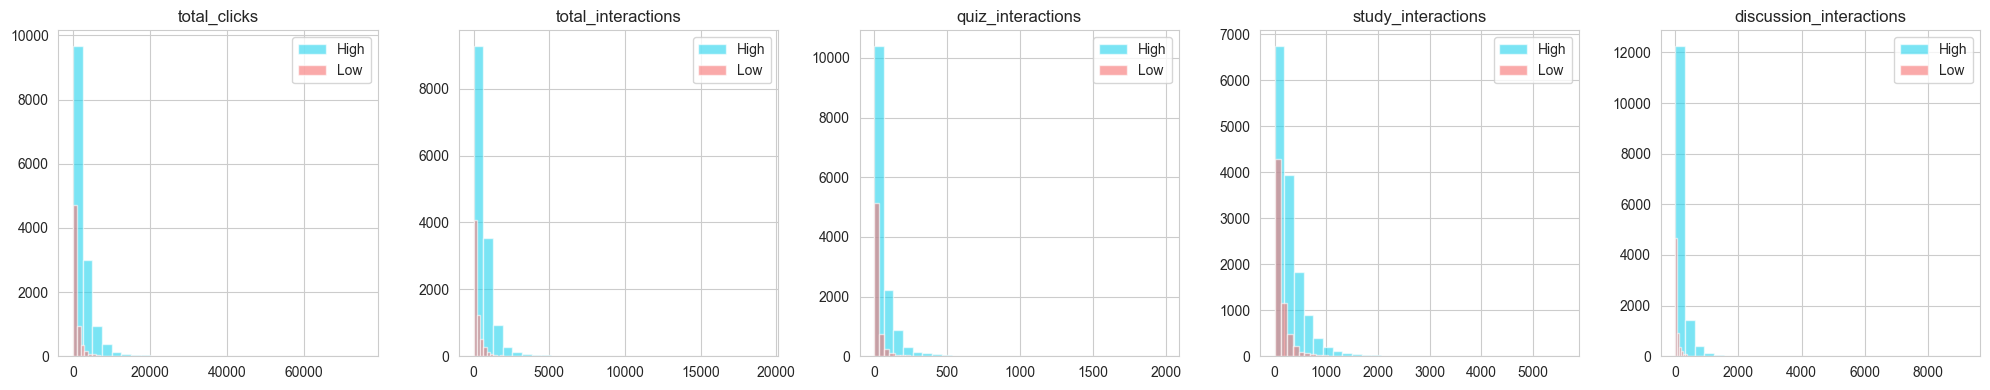

Saved to results/figures/feature_distributions.png


In [10]:
# Feature distributions — static features by group
static_cols = [
    "total_clicks", "total_interactions",
    "quiz_interactions", "study_interactions", "discussion_interactions",
]
static_cols = [c for c in static_cols if c in features.columns]

fig, axes = plt.subplots(1, len(static_cols), figsize=(4 * len(static_cols), 4))

for ax, col in zip(axes, static_cols):
    for group, color in [("High", "#22d3ee"), ("Low", "#f87171")]:
        subset = features[features["performance_group"] == group][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=group)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/feature_distributions.png", dpi=150)
plt.show()
print("Saved to results/figures/feature_distributions.png")

In [11]:
# Pattern feature prevalence by group
pat_cols = [c for c in features.columns if c.startswith("pat_")]

high_prev = features[features["performance_group"] == "High"][pat_cols].mean() * 100
low_prev  = features[features["performance_group"] == "Low"][pat_cols].mean()  * 100

prev_df = pd.DataFrame({
    "High %": high_prev.round(1),
    "Low %":  low_prev.round(1),
    "Diff":   (high_prev - low_prev).round(1),
}).sort_values("Diff", ascending=False)

print("Pattern prevalence by group:")
print(prev_df.to_string())

Pattern prevalence by group:
                                                High %  Low %  Diff
pat_Discussion_Quiz                               92.8   72.8  20.0
pat_External_StudyMaterial_External_Discussion    81.5   61.6  19.8
pat_External_Discussion_External                  81.1   61.7  19.4
pat_Discussion_Navigation_External_Discussion     82.8   63.4  19.4
pat_StudyMaterial_External_External_Discussion    81.5   62.5  19.0
pat_External_External_StudyMaterial_Discussion    81.6   62.8  18.9
pat_Discussion_External_Discussion_Discussion     82.6   63.9  18.7
pat_Discussion_Navigation_Discussion_External     83.1   64.7  18.4
pat_Discussion_External_Discussion_Navigation     83.2   64.9  18.2
pat_Discussion_Navigation_External_Navigation     84.3   67.5  16.8
pat_External_External_Navigation_Navigation       83.3   67.6  15.7


## Save features.csv

In [12]:
output_path = processed_path + "features.csv"
features.to_csv(output_path, index=False)
print(f"Saved {len(features):,} rows to {output_path}")
print(f"Shape: {features.shape}")
print(f"Columns: {features.columns.tolist()}")

Saved 20,788 rows to ../data/processed/features.csv
Shape: (20788, 23)
Columns: ['id_student', 'pat_External_StudyMaterial_External_Discussion', 'pat_StudyMaterial_External_External_Discussion', 'pat_Discussion_Navigation_Discussion_External', 'pat_Discussion_Navigation_External_Navigation', 'pat_External_External_StudyMaterial_Discussion', 'pat_Discussion_External_Discussion_Navigation', 'pat_External_Discussion_External', 'pat_External_External_Navigation_Navigation', 'pat_Discussion_External_Discussion_Discussion', 'pat_Discussion_Navigation_External_Discussion', 'pat_Discussion_Quiz', 'total_clicks', 'total_interactions', 'unique_activity_types', 'pre_course_interactions', 'quiz_interactions', 'study_interactions', 'discussion_interactions', 'navigation_interactions', 'external_interactions', 'datatool_interactions', 'performance_group']


## Verify

In [13]:
verify = pd.read_csv(processed_path + "features.csv")
print("Shape:", verify.shape)
print("Columns:", verify.columns.tolist())
print()
print(verify["performance_group"].value_counts())
print()
verify.head(3)

Shape: (20788, 23)
Columns: ['id_student', 'pat_External_StudyMaterial_External_Discussion', 'pat_StudyMaterial_External_External_Discussion', 'pat_Discussion_Navigation_Discussion_External', 'pat_Discussion_Navigation_External_Navigation', 'pat_External_External_StudyMaterial_Discussion', 'pat_Discussion_External_Discussion_Navigation', 'pat_External_Discussion_External', 'pat_External_External_Navigation_Navigation', 'pat_Discussion_External_Discussion_Discussion', 'pat_Discussion_Navigation_External_Discussion', 'pat_Discussion_Quiz', 'total_clicks', 'total_interactions', 'unique_activity_types', 'pre_course_interactions', 'quiz_interactions', 'study_interactions', 'discussion_interactions', 'navigation_interactions', 'external_interactions', 'datatool_interactions', 'performance_group']

performance_group
High    14323
Low      6465
Name: count, dtype: int64



,id_student,pat_External_StudyMaterial_External_Discussion,pat_StudyMaterial_External_External_Discussion,pat_Discussion_Navigation_Discussion_External,pat_Discussion_Navigation_External_Navigation,pat_External_External_StudyMaterial_Discussion,pat_Discussion_External_Discussion_Navigation,pat_External_Discussion_External,pat_External_External_Navigation_Navigation,pat_Discussion_External_Discussion_Discussion,pat_Discussion_Navigation_External_Discussion,pat_Discussion_Quiz,total_clicks,total_interactions,unique_activity_types,pre_course_interactions,quiz_interactions,study_interactions,discussion_interactions,navigation_interactions,external_interactions,datatool_interactions,performance_group
0,6516,1,1,1,1,1,1,1,1,1,1,0,2791,662,5,53.0,0,276,175,158,49,4,High
1,11391,1,1,1,1,1,1,1,1,1,1,0,934,196,4,11.0,0,100,52,40,4,0,High
2,23629,0,0,0,0,0,0,0,0,0,0,1,161,59,4,3.0,15,4,24,16,0,0,Low
